In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
if "I__hvgs" not in ds.RNA.feats.columns:
    ds.mark_hvgs(
        min_cells=20,
        top_n=500,
        show_plot=False,
    )
normalized = ds.run_normalization(feat_key="hvgs")

Downloading bucket files: 38209567 / 38209567 complete

Downloading bytes: 38209567 / 38209567 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

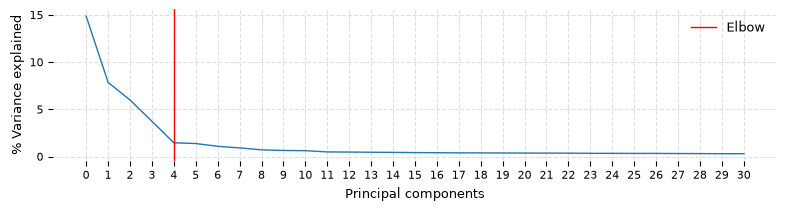

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

In [2]:
cluster_keys = {}
for dimensions in (10, 30, 15):
    pca = ds.run_pca(
        normalized,
        dims=dimensions,
        show_elbow_plot=dimensions == 30,
    )
    if dimensions == 15:
        ds.build_embedding_initialization(pca)
    ann = ds.build_ann_index(pca)
    neighbors = ds.query_neighbors(ann, k=11)
    graph = ds.build_connectivity_map(neighbors)

    label = f"leiden_pca_{dimensions}"
    ds.run_leiden_clustering(
        graph,
        resolution=0.5,
        label=label,
    )
    cluster_keys[dimensions] = f"RNA_{label}"

In [3]:
cluster_counts = pd.Series(
    {
        dimensions: pd.Series(
            ds.cells.fetch(cluster_key, key="I")
        ).nunique()
        for dimensions, cluster_key in cluster_keys.items()
    },
    name="n_clusters",
).rename_axis("pca_dimensions")
cluster_counts

pca_dimensions
10    11
30    10
15    11
Name: n_clusters, dtype: int64

In [4]:
agreement_rows = []
for first, second in combinations(cluster_keys, 2):
    columns = [cluster_keys[first], cluster_keys[second]]
    agreement_rows.append(
        {
            "comparison": f"{first} vs {second} dimensions",
            "ARI": ds.metric_label_concordance(
                columns,
                metric="ari",
            ),
            "NMI": ds.metric_label_concordance(
                columns,
                metric="nmi",
            ),
        }
    )
pd.DataFrame(agreement_rows)

,comparison,ARI,NMI
0,10 vs 30 dimensions,0.652591,0.806898
1,10 vs 15 dimensions,0.698997,0.848419
2,30 vs 15 dimensions,0.886776,0.897774


In [5]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    label="UMAP",
)

Training UMAP: 150 / 150 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='6f6c00dd44ec...')

In [6]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label="densMAP",
)

Training UMAP: 150 / 150 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='f70b4a24aff7...')

In [7]:
ds.run_tsne(
    alpha=10,
    box_h=1,
    early_iter=250,
    max_iter=500,
    verbose=False,
)

ArtifactRef(assay='RNA', kind='embedding', artifact_id='6a4ca8910359...')

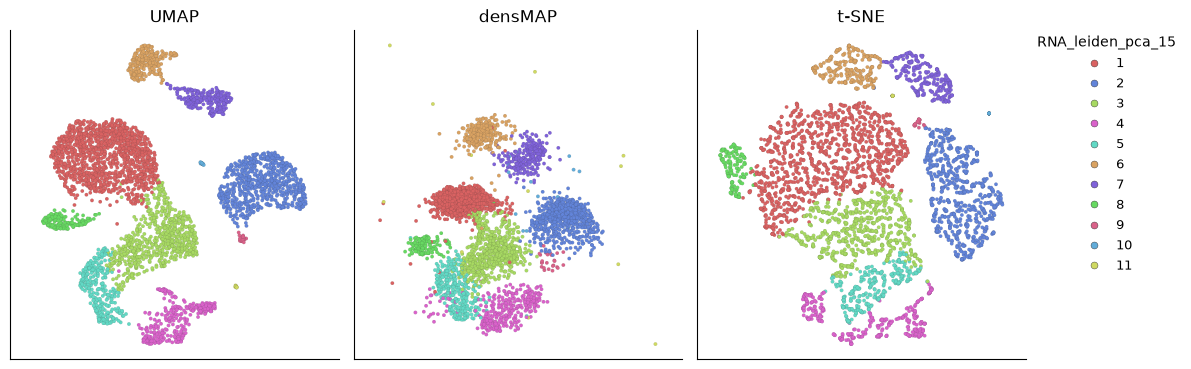

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
layout_comparisons = (
    ("UMAP", "RNA_UMAP"),
    ("densMAP", "RNA_densMAP"),
    ("t-SNE", "RNA_tSNE"),
)
for index, (axis, (title, layout_key)) in enumerate(
    zip(axes, layout_comparisons, strict=True)
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by=cluster_keys[15],
        legend_loc="right",
        show_legend=index == 2,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()
figure